In [1]:
import numpy as np
import pandas as pd

#### Load the dataset and inspect shape, columns, dtypes


In [2]:
ipl_data = pd.read_csv(
    "matches.csv",
    sep = ',',
    index_col = 0)
print(ipl_data)

     season       city        date                        team1  \
id                                                                
1      2017  Hyderabad  2017-04-05          Sunrisers Hyderabad   
2      2017       Pune  2017-04-06               Mumbai Indians   
3      2017     Rajkot  2017-04-07                Gujarat Lions   
4      2017     Indore  2017-04-08       Rising Pune Supergiant   
5      2017  Bangalore  2017-04-08  Royal Challengers Bangalore   
..      ...        ...         ...                          ...   
632    2016     Raipur  2016-05-22             Delhi Daredevils   
633    2016  Bangalore  2016-05-24                Gujarat Lions   
634    2016      Delhi  2016-05-25          Sunrisers Hyderabad   
635    2016      Delhi  2016-05-27                Gujarat Lions   
636    2016  Bangalore  2016-05-29          Sunrisers Hyderabad   

                           team2                  toss_winner toss_decision  \
id                                               

In [3]:
print("Shape:")
print(ipl_data.shape)
print("\nColumns:")
print(ipl_data.columns)
print("\nInfo:")
print(ipl_data.info())
print("\nDescribe:")
print(ipl_data.describe())

Shape:
(636, 17)

Columns:
Index(['season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2',
       'umpire3'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
Index: 636 entries, 1 to 636
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   season           636 non-null    int64  
 1   city             629 non-null    object 
 2   date             636 non-null    object 
 3   team1            636 non-null    object 
 4   team2            636 non-null    object 
 5   toss_winner      636 non-null    object 
 6   toss_decision    636 non-null    object 
 7   result           636 non-null    object 
 8   dl_applied       636 non-null    int64  
 9   winner           633 non-null    object 
 10  win_by_runs      636 non-null    int64  
 11  win_by_w

#### Check for null values and handle them


In [4]:
ipl_data['city'] = ipl_data['city'].fillna('Unknown')
ipl_data['umpire1'] = ipl_data['umpire1'].fillna('Unknown')
ipl_data['umpire2'] = ipl_data['umpire2'].fillna('Unknown')
ipl_data['player_of_match'] = ipl_data['player_of_match'].fillna('No award')
ipl_data['winner'] = ipl_data['winner'].fillna('No result')

In [5]:
ipl_data.drop(columns = ['umpire3'],inplace = True)

In [6]:
print(ipl_data.head(5))

    season       city        date                        team1  \
id                                                               
1     2017  Hyderabad  2017-04-05          Sunrisers Hyderabad   
2     2017       Pune  2017-04-06               Mumbai Indians   
3     2017     Rajkot  2017-04-07                Gujarat Lions   
4     2017     Indore  2017-04-08       Rising Pune Supergiant   
5     2017  Bangalore  2017-04-08  Royal Challengers Bangalore   

                          team2                  toss_winner toss_decision  \
id                                                                           
1   Royal Challengers Bangalore  Royal Challengers Bangalore         field   
2        Rising Pune Supergiant       Rising Pune Supergiant         field   
3         Kolkata Knight Riders        Kolkata Knight Riders         field   
4               Kings XI Punjab              Kings XI Punjab         field   
5              Delhi Daredevils  Royal Challengers Bangalore         

#### Checking duplicate rows

In [7]:
print(ipl_data[ipl_data.duplicated()])

Empty DataFrame
Columns: [season, city, date, team1, team2, toss_winner, toss_decision, result, dl_applied, winner, win_by_runs, win_by_wickets, player_of_match, venue, umpire1, umpire2]
Index: []


#### seasons, teams, and matches in the dataset

In [8]:
Seasons = ipl_data['season'].unique()
Venue = ipl_data['venue'].unique()
Teams = pd.concat([ipl_data['team1'],ipl_data['team2']])
print(f"Seasons: {Seasons}")
print()
print(f"Venue: {Venue}")
print()
print(f"Teams: {Teams.unique()}")

Seasons: [2017 2008 2009 2010 2011 2012 2013 2014 2015 2016]

Venue: ['Rajiv Gandhi International Stadium, Uppal'
 'Maharashtra Cricket Association Stadium'
 'Saurashtra Cricket Association Stadium' 'Holkar Cricket Stadium'
 'M Chinnaswamy Stadium' 'Wankhede Stadium' 'Eden Gardens'
 'Feroz Shah Kotla' 'Punjab Cricket Association IS Bindra Stadium, Mohali'
 'Green Park' 'Punjab Cricket Association Stadium, Mohali'
 'Sawai Mansingh Stadium' 'MA Chidambaram Stadium, Chepauk'
 'Dr DY Patil Sports Academy' 'Newlands' "St George's Park" 'Kingsmead'
 'SuperSport Park' 'Buffalo Park' 'New Wanderers Stadium'
 'De Beers Diamond Oval' 'OUTsurance Oval' 'Brabourne Stadium'
 'Sardar Patel Stadium, Motera' 'Barabati Stadium'
 'Vidarbha Cricket Association Stadium, Jamtha'
 'Himachal Pradesh Cricket Association Stadium' 'Nehru Stadium'
 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium'
 'Subrata Roy Sahara Stadium'
 'Shaheed Veer Narayan Singh International Stadium'
 'JSCA International Stadium C

#### Which team has played the most matches?

In [9]:
team1_count = ipl_data['team1'].value_counts()
team2_count = ipl_data['team2'].value_counts()
total_matches = team1_count.add(team2_count, fill_value = 0).astype(int)
total_matches = total_matches.sort_values(ascending = False)
print(total_matches)

Mumbai Indians                 157
Royal Challengers Bangalore    152
Kings XI Punjab                148
Kolkata Knight Riders          148
Delhi Daredevils               147
Chennai Super Kings            131
Rajasthan Royals               118
Sunrisers Hyderabad             76
Deccan Chargers                 75
Pune Warriors                   46
Gujarat Lions                   30
Rising Pune Supergiant          16
Kochi Tuskers Kerala            14
Rising Pune Supergiants         14
Name: count, dtype: int64


In [10]:
print(total_matches.head(3))

Mumbai Indians                 157
Royal Challengers Bangalore    152
Kings XI Punjab                148
Name: count, dtype: int64


#### How many matches were played per season

In [11]:
matches_per_season = ipl_data.groupby('season')['season'].count()
print(matches_per_season)

season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
Name: season, dtype: int64


#### Which team has won the most matches overall

In [12]:
team_won_matches = ipl_data['winner'].value_counts()
print(team_won_matches)

winner
Mumbai Indians                 92
Chennai Super Kings            79
Kolkata Knight Riders          77
Royal Challengers Bangalore    73
Kings XI Punjab                70
Rajasthan Royals               63
Delhi Daredevils               62
Sunrisers Hyderabad            42
Deccan Chargers                29
Gujarat Lions                  13
Pune Warriors                  12
Rising Pune Supergiant         10
Kochi Tuskers Kerala            6
Rising Pune Supergiants         5
No result                       3
Name: count, dtype: int64


#### How many matches were won by batting first 

In [13]:
toss_decision_win = ipl_data.groupby(['toss_decision','toss_winner'])['winner'].count()
print(toss_decision_win)

toss_decision  toss_winner                
bat            Chennai Super Kings            44
               Deccan Chargers                24
               Delhi Daredevils               26
               Gujarat Lions                   1
               Kings XI Punjab                25
               Kochi Tuskers Kerala            3
               Kolkata Knight Riders          30
               Mumbai Indians                 40
               Pune Warriors                  11
               Rajasthan Royals               28
               Rising Pune Supergiants         3
               Royal Challengers Bangalore    20
               Sunrisers Hyderabad            18
field          Chennai Super Kings            22
               Deccan Chargers                19
               Delhi Daredevils               46
               Gujarat Lions                  14
               Kings XI Punjab                43
               Kochi Tuskers Kerala            5
               Kolkata Kni

In [14]:
print(toss_decision_win['bat'].sort_values(ascending = False))

toss_winner
Chennai Super Kings            44
Mumbai Indians                 40
Kolkata Knight Riders          30
Rajasthan Royals               28
Delhi Daredevils               26
Kings XI Punjab                25
Deccan Chargers                24
Royal Challengers Bangalore    20
Sunrisers Hyderabad            18
Pune Warriors                  11
Kochi Tuskers Kerala            3
Rising Pune Supergiants         3
Gujarat Lions                   1
Name: winner, dtype: int64


#### Which city hosts the most matches

In [15]:
host_city = ipl_data['city'].value_counts()
print(host_city)
print(f'\nMost matches are hosted by city: {host_city.idxmax()}')

city
Mumbai            85
Bangalore         66
Kolkata           61
Delhi             60
Hyderabad         49
Chennai           48
Chandigarh        46
Jaipur            33
Pune              32
Durban            15
Ahmedabad         12
Centurion         12
Visakhapatnam     11
Rajkot            10
Dharamsala         9
Johannesburg       8
Cape Town          7
Abu Dhabi          7
Ranchi             7
Port Elizabeth     7
Cuttack            7
Unknown            7
Raipur             6
Sharjah            6
Kochi              5
Indore             5
Kanpur             4
Nagpur             3
Kimberley          3
East London        3
Bloemfontein       2
Name: count, dtype: int64

Most matches are hosted by city: Mumbai


#### Does winning the toss help in winning the match

In [16]:
toss_win_match_win = ipl_data['winner'] == ipl_data['toss_winner']
toss_helped_count = toss_win_match_win.value_counts()
print(f'Total win and loss counts: {toss_helped_count}')
total = len(ipl_data)
percentage = (toss_helped_count[True]/total)*100
print(f"Toss winner won the match {percentage:.2f}% of the time")

Total win and loss counts: True     325
False    311
Name: count, dtype: int64
Toss winner won the match 51.10% of the time


#### Which team wins the toss the most

In [17]:
print(ipl_data['toss_winner'].value_counts())

toss_winner
Mumbai Indians                 85
Kolkata Knight Riders          78
Delhi Daredevils               72
Royal Challengers Bangalore    70
Kings XI Punjab                68
Chennai Super Kings            66
Rajasthan Royals               63
Deccan Chargers                43
Sunrisers Hyderabad            35
Pune Warriors                  20
Gujarat Lions                  15
Kochi Tuskers Kerala            8
Rising Pune Supergiants         7
Rising Pune Supergiant          6
Name: count, dtype: int64


#### Count of player of match award winning

In [24]:
print(ipl_data['player_of_match'].value_counts())

player_of_match
CH Gayle          18
YK Pathan         16
AB de Villiers    15
DA Warner         15
SK Raina          14
                  ..
MR Marsh           1
A Singh            1
P Parameswaran     1
KV Sharma          1
BCJ Cutting        1
Name: count, Length: 202, dtype: int64


#### Top 10 players by Player of the Match count per season

In [19]:
print(ipl_data.groupby(['season','player_of_match'])['player_of_match'].count().sort_values(ascending = False).head(10))

season  player_of_match
2011    CH Gayle           6
2008    SE Marsh           5
2016    V Kohli            5
2012    CH Gayle           5
2013    MEK Hussey         5
2016    RG Sharma          4
2008    YK Pathan          4
2016    AB de Villiers     4
2010    SR Tendulkar       4
2014    GJ Maxwell         4
Name: player_of_match, dtype: int64


#### Closest matches (wins by 1-5 runs)

In [20]:
close_match_win = ipl_data[ipl_data['win_by_runs'] < 6]
print(close_match_win)

     season           city        date                   team1  \
id                                                               
2      2017           Pune  2017-04-06          Mumbai Indians   
3      2017         Rajkot  2017-04-07           Gujarat Lions   
4      2017         Indore  2017-04-08  Rising Pune Supergiant   
6      2017      Hyderabad  2017-04-09           Gujarat Lions   
7      2017         Mumbai  2017-04-09   Kolkata Knight Riders   
..      ...            ...         ...                     ...   
629    2016  Visakhapatnam  2016-05-21         Kings XI Punjab   
630    2016         Kanpur  2016-05-21          Mumbai Indians   
632    2016         Raipur  2016-05-22        Delhi Daredevils   
633    2016      Bangalore  2016-05-24           Gujarat Lions   
635    2016          Delhi  2016-05-27           Gujarat Lions   

                           team2                  toss_winner toss_decision  \
id                                                            

#### Which team dominated by most runs in which season?

In [21]:
idx = ipl_data['win_by_runs'].idxmax()
print(ipl_data.loc[idx, ['season', 'winner', 'win_by_runs']])

season                   2017
winner         Mumbai Indians
win_by_runs               146
Name: 44, dtype: object


#### Has the number of matches grown over seasons?

In [22]:
matches_per_season = ipl_data.groupby('season')['date'].count()
print(matches_per_season)
print(f"Max matches palyed {matches_per_season.max()} in the season {matches_per_season.idxmax()}")
print(f"Min matches palyed {matches_per_season.min()} in the season {matches_per_season.idxmin()}")

season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
Name: date, dtype: int64
Max matches palyed 76 in the season 2013
Min matches palyed 57 in the season 2009


#### Plot — Matches Per Season (Line Chart)

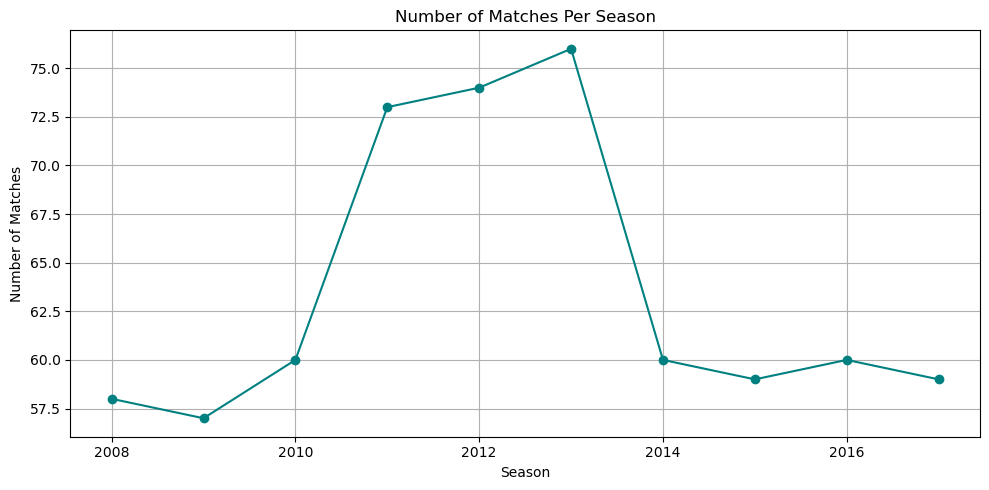

In [23]:
import matplotlib.pyplot as plt

matches_per_season.plot(kind='line', marker='o', figsize=(10,5), color='teal')

plt.title('Number of Matches Per Season')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.grid(True)
plt.tight_layout()
plt.show()